In [147]:
import sys
from pathlib import Path
import pandas as pd

# Set the project root manually
project_root = Path("C:/Users/dinat/Υπολογιστής/Pfizer Masterclass/airbnb-price-prediction-app")
sys.path.append(str(project_root))

In [148]:
data = pd.read_csv(project_root / 'data/listings.csv')

In [149]:
# ── Date Feature Engineering ──────────────────────────────────────────────────

# Convert to datetime before anything else
for col in ["last_scraped", "host_since", "first_review", "last_review"]:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors="coerce")

# Reference date = most recent scrape date
reference_date = data["last_scraped"].max()

# --- host_since → host tenure in days ---
if "host_since" in data.columns:
    data["host_tenure_days"] = (reference_date - data["host_since"]).dt.days
    data.drop(columns=["host_since"], inplace=True)

# --- first_review → days since first review (proxy for listing age) ---
if "first_review" in data.columns:
    data["days_since_first_review"] = (reference_date - data["first_review"]).dt.days
    data.drop(columns=["first_review"], inplace=True)

# --- last_review → days since last review (proxy for recent activity) ---
if "last_review" in data.columns:
    data["days_since_last_review"] = (reference_date - data["last_review"]).dt.days
    data.drop(columns=["last_review"], inplace=True)

if "last_scraped" in data.columns:
    data.drop(columns=["last_scraped"], inplace=True)

print("Date columns created:", [c for c in data.columns if "days" in c or "tenure" in c])

Date columns created: ['host_tenure_days', 'days_since_first_review', 'days_since_last_review']


In [150]:
# Drop columns with unecessary information for modeling

data = data.drop(columns=["description", 
                          "host_about",
                          "name", 
                          "host_name", 
                          "host_picture_url", 
                          "host_thumbnail_url", 
                          "host_url", 
                          "id", 
                          "license", 
                          "listing_url", 
                          "neighborhood_overview", 
                          "picture_url",
                          "scrape_id",
                          "host_location",
                          "host_has_profile_pic",
                          "neighbourhood",
                          "calendar_last_scraped",
                          "host_neighbourhood",
                          "property_type",])

In [153]:
# Full translation map for neighbourhood_cleansed (44 values)
neighbourhood_en = {
    "ΑΜΠΕΛΟΚΗΠΟΙ": "Ampelokipoi",
    "ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ": "Commercial Triangle-Plaka",
    "ΚΕΡΑΜΕΙΚΟΣ": "Kerameikos",
    "ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ": "Agios Nikolaos",
    "ΠΑΓΚΡΑΤΙ": "Pagrati",
    "ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ": "Agios Konstantinos-Vathis Square",
    "ΣΤΑΔΙΟ": "Stadio",
    "ΑΚΑΔΗΜΙΑ ΠΛΑΤΩΝΟΣ": "Plato Academy",
    "ΑΚΡΟΠΟΛΗ": "Acropolis",
    "ΝΕΑ ΚΥΨΕΛΗ": "Nea Kypseli",
    "ΚΟΛΩΝΑΚΙ": "Kolonaki",
    "ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ": "Museum-Exarchia-Neapoli",
    "ΠΑΤΗΣΙΑ": "Patisia",
    "ΓΚΑΖΙ": "Gazi",
    "ΑΝΩ ΠΑΤΗΣΙΑ": "Ano Patisia",
    "ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ": "Attiki Square",
    "ΠΛΑΤΕΙΑ ΑΜΕΡΙΚΗΣ": "Amerikis Square",
    "ΙΛΙΣΙΑ": "Ilisia",
    "ΘΗΣΕΙΟ": "Thiseio",
    "ΠΕΔΙΟ ΑΡΕΩΣ": "Pedion Areos",
    "ΚΟΥΚΑΚΙ-ΜΑΚΡΥΓΙΑΝΝΗ": "Koukaki-Makrygianni",
    "ΠΕΤΡΑΛΩΝΑ": "Petralona",
    "ΓΟΥΒΑ": "Gouva",
    "1Ο ΝΕΚΡΟΤΑΦΕΙΟ": "First Cemetery",
    "ΠΡΟΜΠΟΝΑ": "Prompona",
    "ΓΟΥΔΙ": "Goudi",
    "ΝΕΟΣ ΚΟΣΜΟΣ": "Neos Kosmos",
    "ΚΟΛΩΝΟΣ": "Kolonos",
    "ΝΙΡΒΑΝΑ": "Nirvana",
    "ΚΥΨΕΛΗ": "Kypseli",
    "ΑΝΩ ΚΥΨΕΛΗ": "Ano Kypseli",
    "ΖΑΠΠΕΙΟ": "Zappeio",
    "ΛΥΚΑΒΗΤΤΟΣ": "Lycabettus",
    "ΒΟΤΑΝΙΚΟΣ": "Votanikos",
    "ΓΚΥΖΗ": "Gkyzi",
    "ΣΕΠΟΛΙΑ": "Sepolia",
    "ΣΤΑΘΜΟΣ ΛΑΡΙΣΗΣ": "Larissis Station",
    "ΠΟΛΥΓΩΝΟ": "Polygono",
    "ΠΕΝΤΑΓΩΝΟ": "Pentagon",
    "ΑΓΙΟΣ ΕΛΕΥΘΕΡΙΟΣ": "Agios Eleftherios",
    "ΕΛΛΗΝΟΡΩΣΩΝ": "Ellinorosson",
    "ΡΗΓΙΛΛΗΣ": "Rigillis",
    "ΚΟΛΟΚΥΝΘΟΥ": "Kolokynthou",
    "ΡΙΖΟΥΠΟΛΗ": "Rizoupoli",
}

# Apply translation
data["neighbourhood_cleansed"] = data["neighbourhood_cleansed"].map(neighbourhood_en)

# Safety check
print("Unmapped values:", data["neighbourhood_cleansed"].isna().sum())
print(data["neighbourhood_cleansed"].value_counts().head())

Unmapped values: 0
neighbourhood_cleansed
Commercial Triangle-Plaka           1866
Koukaki-Makrygianni                  841
Neos Kosmos                          713
Museum-Exarchia-Neapoli              699
Agios Konstantinos-Vathis Square     599
Name: count, dtype: int64


In [154]:
import numpy as np

# Replace string "nan" / "NaN" / "None" with actual NaN
data.replace({"nan": np.nan, "NaN": np.nan, "None": np.nan, "none": np.nan, "": np.nan}, inplace=True)

# Drop variable with 100% missing values
data = data.loc[:, data.isna().mean() < 1.0]

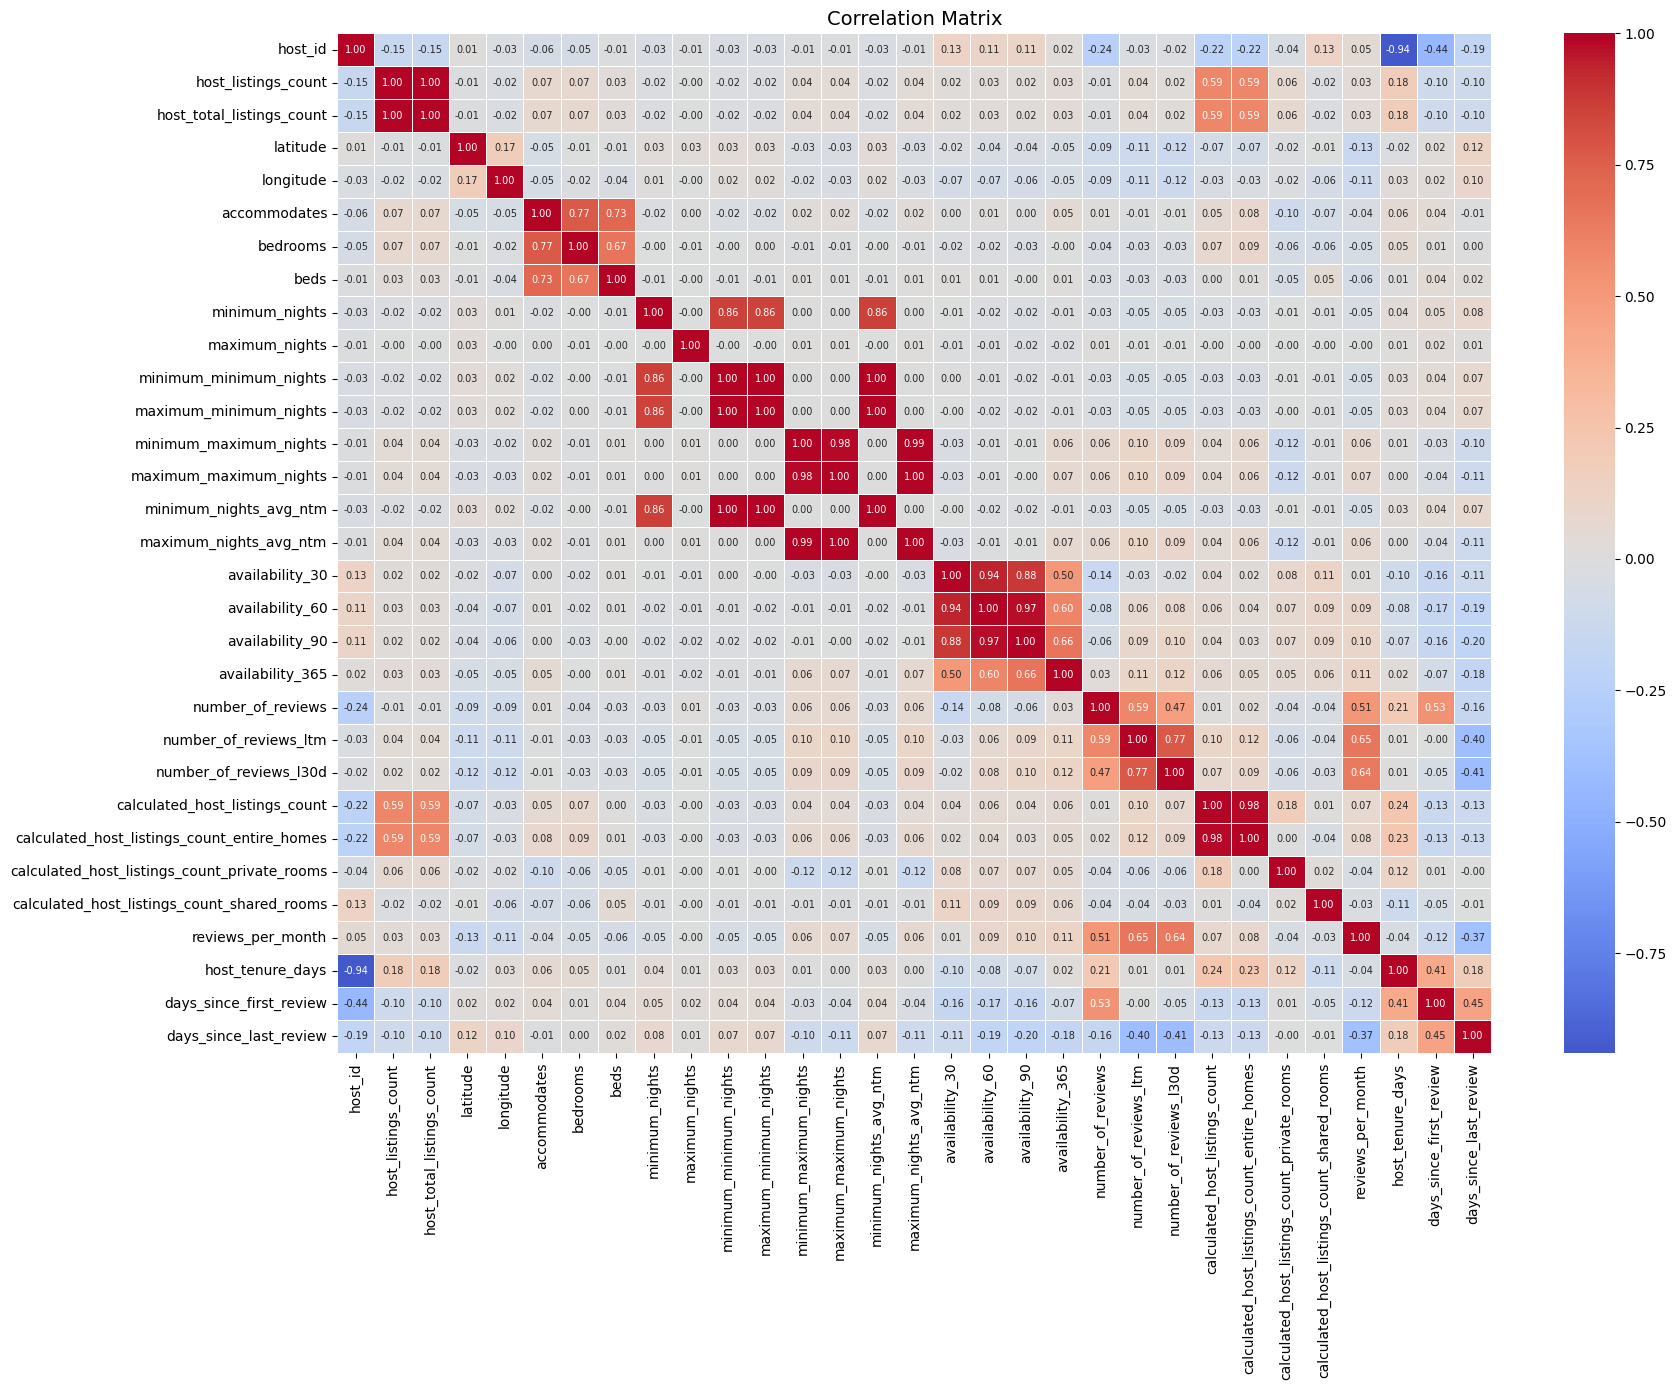

Pairs with |correlation| >= 0.85:


,variable_1,variable_2,correlation
30,host_listings_count,host_total_listings_count,1.000000
258,minimum_minimum_nights,minimum_nights_avg_ntm,0.998767
277,maximum_minimum_nights,minimum_nights_avg_ntm,0.998163
313,maximum_maximum_nights,maximum_nights_avg_ntm,0.996645
255,minimum_minimum_nights,maximum_minimum_nights,0.995539
296,minimum_maximum_nights,maximum_nights_avg_ntm,0.990994
294,minimum_maximum_nights,maximum_maximum_nights,0.983185
437,calculated_host_listings_count,calculated_host_listings_count_entire_homes,0.982930
374,availability_60,availability_90,0.973927
360,availability_30,availability_60,0.938032



Suggested columns to drop (10):
{'maximum_nights_avg_ntm', 'availability_90', 'maximum_minimum_nights', 'minimum_minimum_nights', 'host_total_listings_count', 'host_tenure_days', 'calculated_host_listings_count_entire_homes', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'availability_60'}


In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Correlation matrix on numeric columns only ---
numeric_data = data.select_dtypes(include=["int64", "float64"])
corr_matrix = numeric_data.corr()

# --- 2. Heatmap ---
plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

# --- 3. Find pairs with |correlation| >= threshold ---
threshold = 0.85

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "variable_1", "level_1": "variable_2", 0: "correlation"})
    .query("abs(correlation) >= @threshold")
    .sort_values("correlation", ascending=False)
)

print(f"Pairs with |correlation| >= {threshold}:")
display(high_corr_pairs)

# --- 4. Columns to drop (the second column from each high-corr pair) ---
cols_to_drop = set(high_corr_pairs["variable_2"].tolist())
print(f"\nSuggested columns to drop ({len(cols_to_drop)}):")
print(cols_to_drop)

In [156]:
# Drop highly correlated columns
data = data.drop(columns=list(cols_to_drop))

In [157]:
# ── 1. Clean price column (string → float) ───────────────────────────────────
data["price"] = (
    data["price"]
    .astype(str)
    .str.replace("[$,]", "", regex=True)
    .str.strip()
)
data["price"] = pd.to_numeric(data["price"], errors="coerce")
data = data[data["price"] > 0].copy()  # remove zero / NaN prices

print(f"After price cleaning: {data.shape[0]} rows")

After price cleaning: 9582 rows


In [158]:
# ── Outlier Detection ────────────────────────────────────────────────────────

numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()

# --- 1. IQR-based outlier summary table ---
rows_outliers = []
for col in numeric_cols:
    s = data[col].dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((s < lower) | (s > upper)).sum()
    rows_outliers.append({
        "column": col,
        "min": s.min(),
        "Q1": Q1,
        "median": s.median(),
        "Q3": Q3,
        "max": s.max(),
        "IQR_lower_fence": lower,
        "IQR_upper_fence": upper,
        "n_outliers": n_outliers,
        "outlier_pct": round(100 * n_outliers / len(s), 2)
    })

outlier_summary = pd.DataFrame(rows_outliers).sort_values("outlier_pct", ascending=False)
display(outlier_summary)

,column,min,Q1,median,Q3,max,IQR_lower_fence,IQR_upper_fence,n_outliers,outlier_pct
10,minimum_maximum_nights,1.00000,1.125000e+03,1.125000e+03,1.125000e+03,4.444000e+03,1.125000e+03,1.125000e+03,2015,21.03
1,host_listings_count,0.00000,1.000000e+00,3.000000e+00,1.100000e+01,2.095000e+03,-1.400000e+01,2.600000e+01,1327,13.85
17,calculated_host_listings_count_private_rooms,0.00000,0.000000e+00,0.000000e+00,0.000000e+00,4.300000e+01,0.000000e+00,0.000000e+00,1282,13.38
16,calculated_host_listings_count,1.00000,1.000000e+00,3.000000e+00,9.000000e+00,1.560000e+02,-1.100000e+01,2.100000e+01,1280,13.36
13,number_of_reviews,0.00000,2.000000e+00,1.200000e+01,5.200000e+01,7.450000e+02,-7.300000e+01,1.270000e+02,946,9.87
8,minimum_nights,1.00000,1.000000e+00,2.000000e+00,2.000000e+00,1.000000e+03,-5.000000e-01,3.500000e+00,902,9.41
14,number_of_reviews_ltm,0.00000,0.000000e+00,2.000000e+00,1.200000e+01,3.460000e+02,-1.800000e+01,3.000000e+01,740,7.72
7,price,9.00000,3.600000e+01,5.000000e+01,8.000000e+01,8.000000e+03,-3.000000e+01,1.460000e+02,722,7.53
19,reviews_per_month,0.01000,4.300000e-01,1.200000e+00,2.640000e+00,2.800000e+01,-2.885000e+00,5.955000e+00,352,4.47
4,accommodates,1.00000,2.000000e+00,4.000000e+00,4.000000e+00,1.600000e+01,-1.000000e+00,7.000000e+00,427,4.46


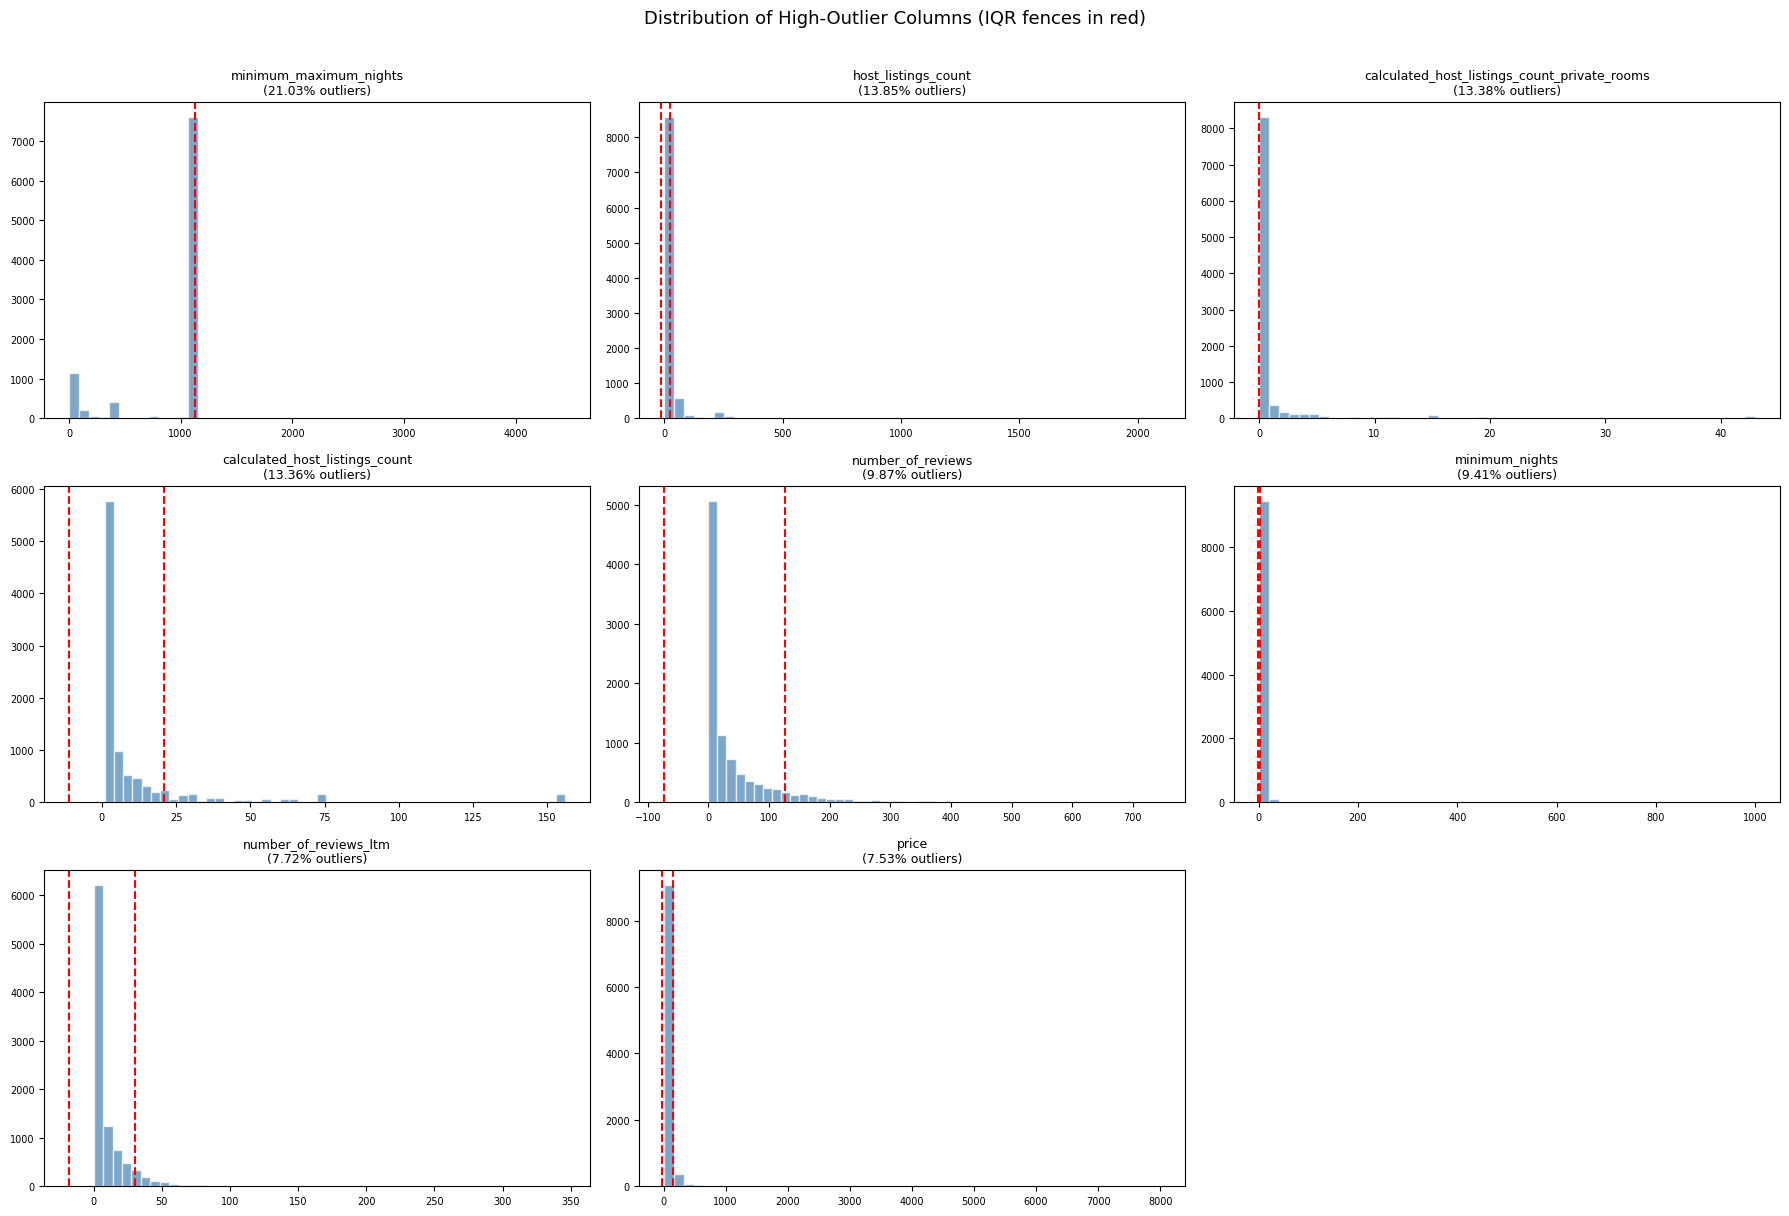

In [159]:
# --- 3. Distribution plots for high-outlier columns (outlier_pct > 5%) ---
high_outlier_cols = outlier_summary[outlier_summary["outlier_pct"] > 5]["column"].tolist()

if high_outlier_cols:
    n_cols = 3
    n_rows = -(-len(high_outlier_cols) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(high_outlier_cols):
        s = data[col].dropna()
        axes[i].hist(s, bins=50, color="steelblue", alpha=0.7, edgecolor="white")
        # Mark IQR fences
        row = outlier_summary[outlier_summary["column"] == col].iloc[0]
        axes[i].axvline(row["IQR_lower_fence"], color="red", linestyle="--", label="IQR fence")
        axes[i].axvline(row["IQR_upper_fence"], color="red", linestyle="--")
        axes[i].set_title(f"{col}\n({row['outlier_pct']}% outliers)", fontsize=9)
        axes[i].tick_params(labelsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Distribution of High-Outlier Columns (IQR fences in red)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No columns with >5% outliers found.")

In [160]:
# ── Cap outliers with median (IQR-based) ─────────────────────────────────────

cols_for_outlier_treatment = [
    "price",
    "minimum_nights",
    "maximum_nights",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "reviews_per_month",
    "number_of_reviews",
]

cols_for_outlier_treatment = [c for c in cols_for_outlier_treatment if c in data.columns]

for col in cols_for_outlier_treatment:
    s = data[col].dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    median = s.median()

    outlier_mask = (data[col] < lower) | (data[col] > upper)
    n_replaced = outlier_mask.sum()
    data.loc[outlier_mask, col] = median
    print(f"  {col}: replaced {n_replaced} outliers with median={median:.2f}")

print(f"\nShape unchanged: {data.shape}")

  price: replaced 722 outliers with median=50.00
  minimum_nights: replaced 902 outliers with median=2.00
  maximum_nights: replaced 2 outliers with median=1125.00
  accommodates: replaced 427 outliers with median=4.00
  bedrooms: replaced 200 outliers with median=1.00
  beds: replaced 145 outliers with median=2.00
  reviews_per_month: replaced 352 outliers with median=1.20
  number_of_reviews: replaced 946 outliers with median=12.00

Shape unchanged: (9582, 34)


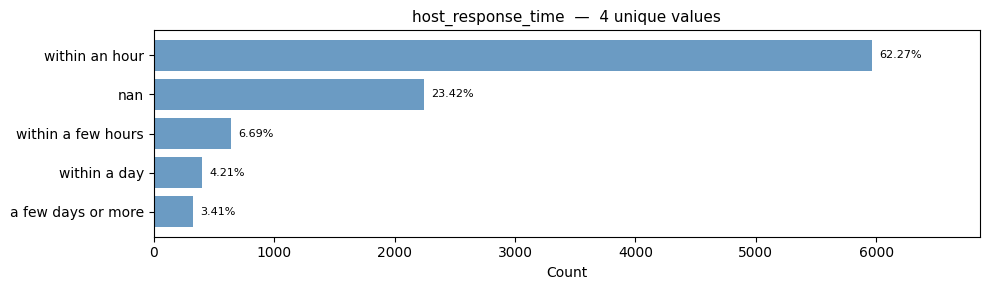

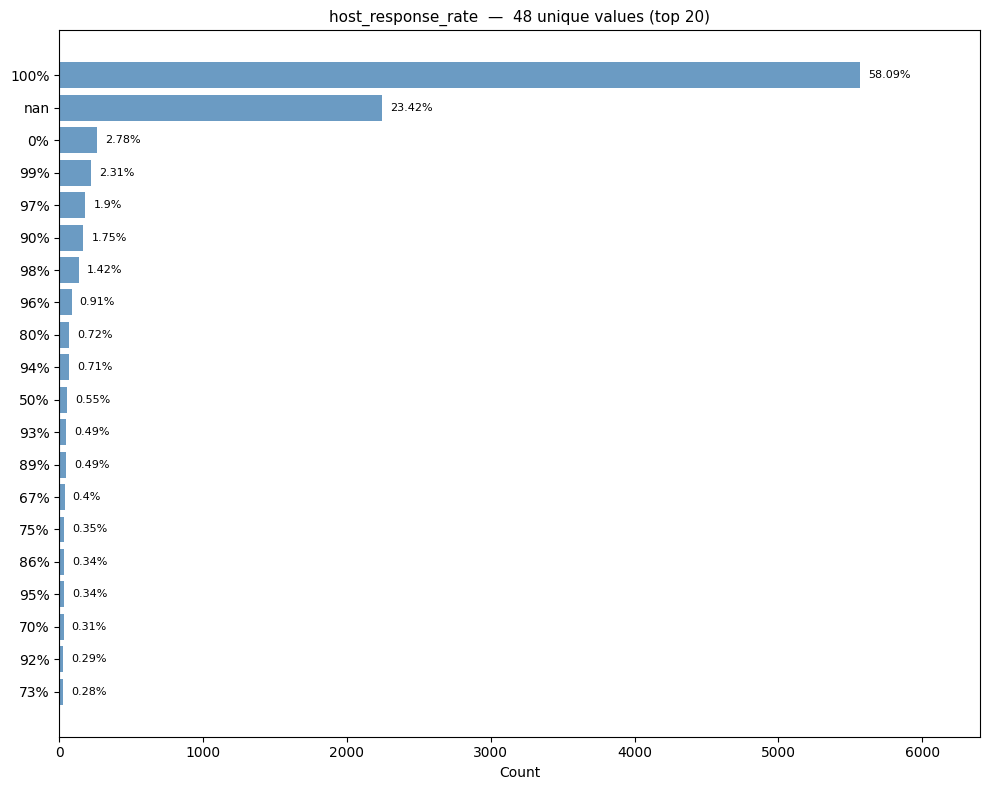

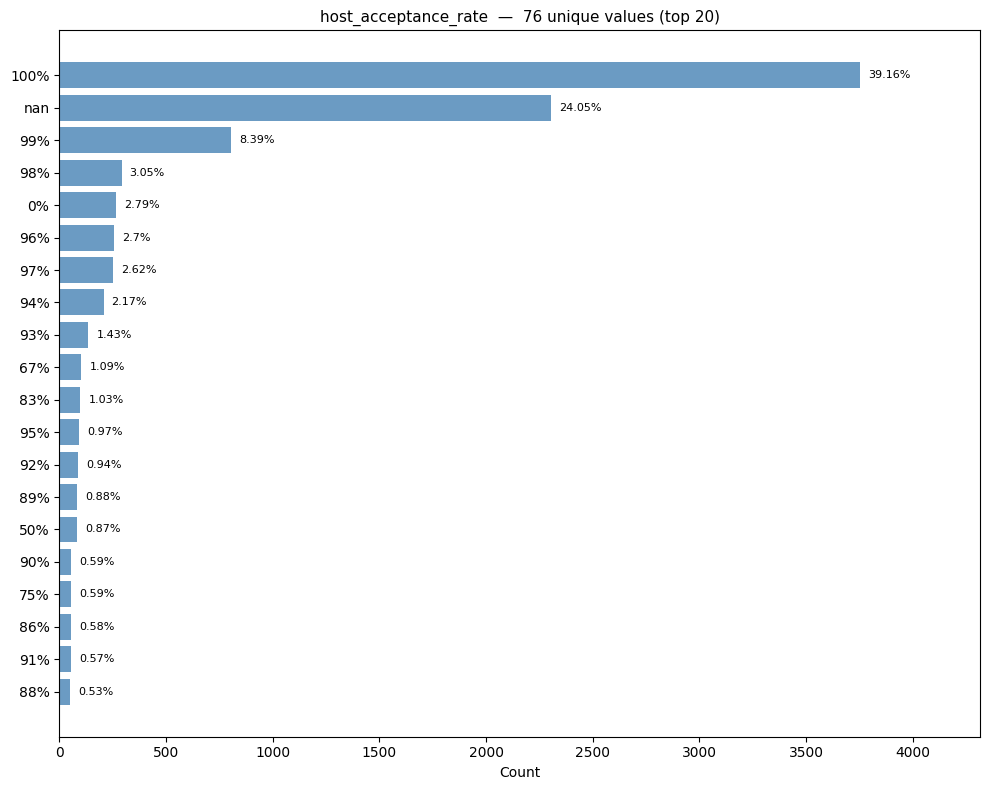

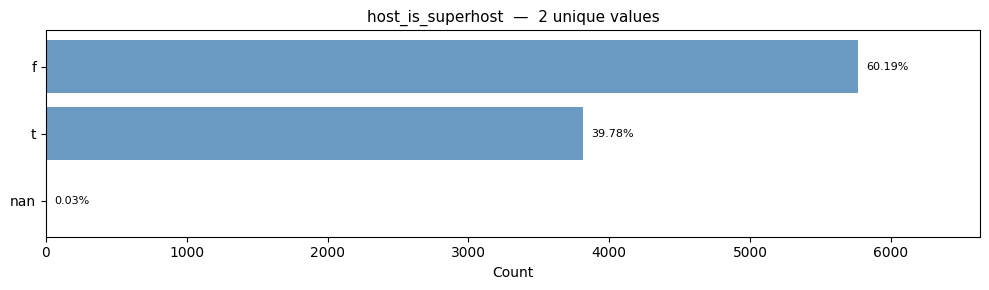

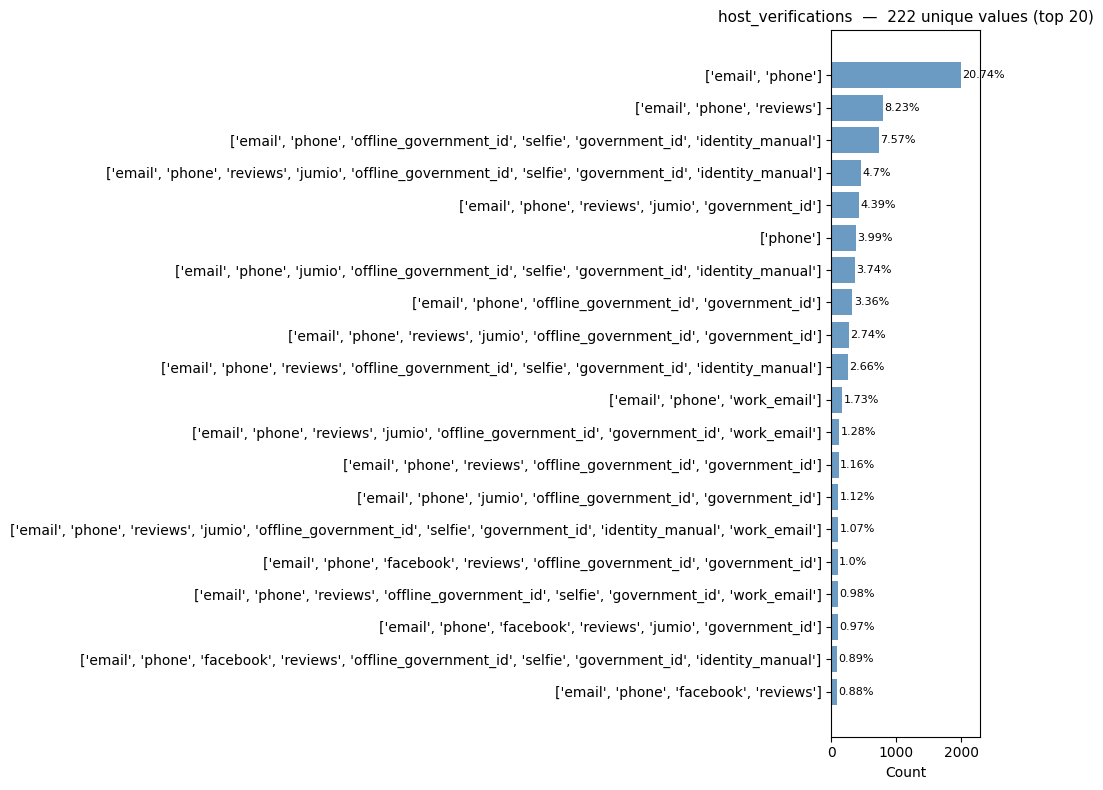

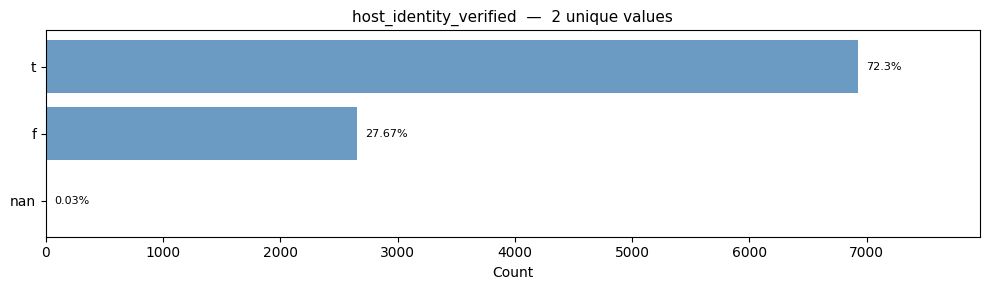

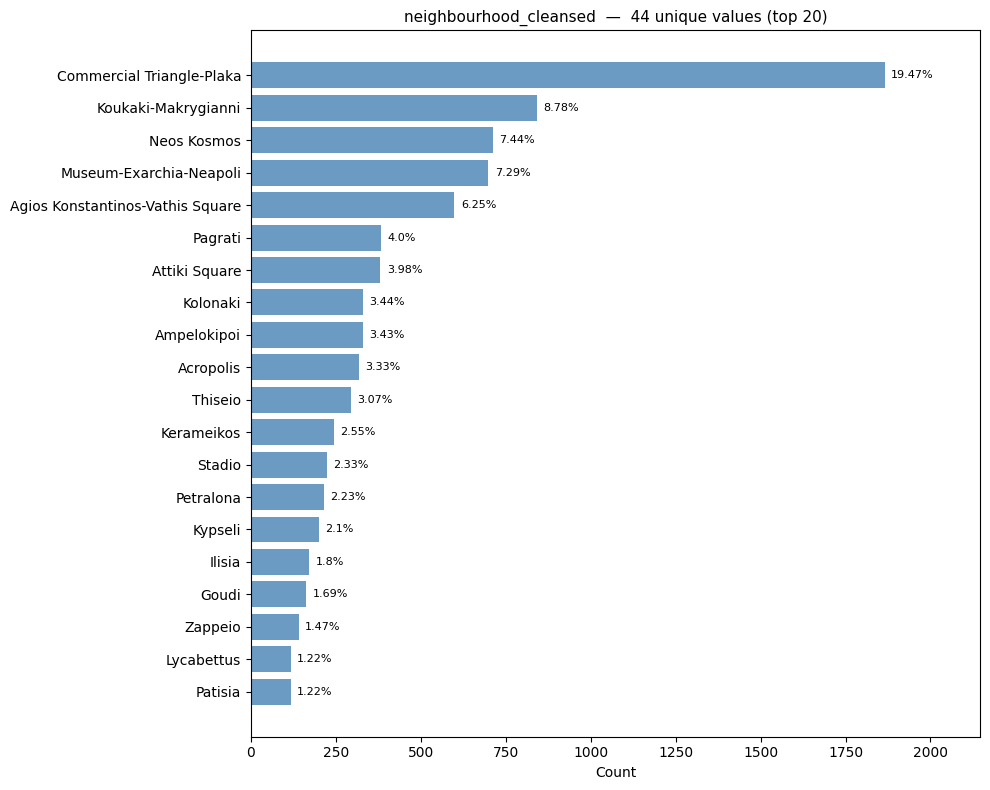

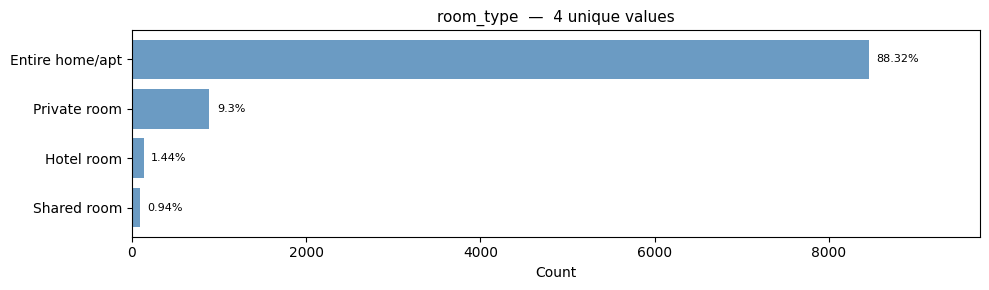

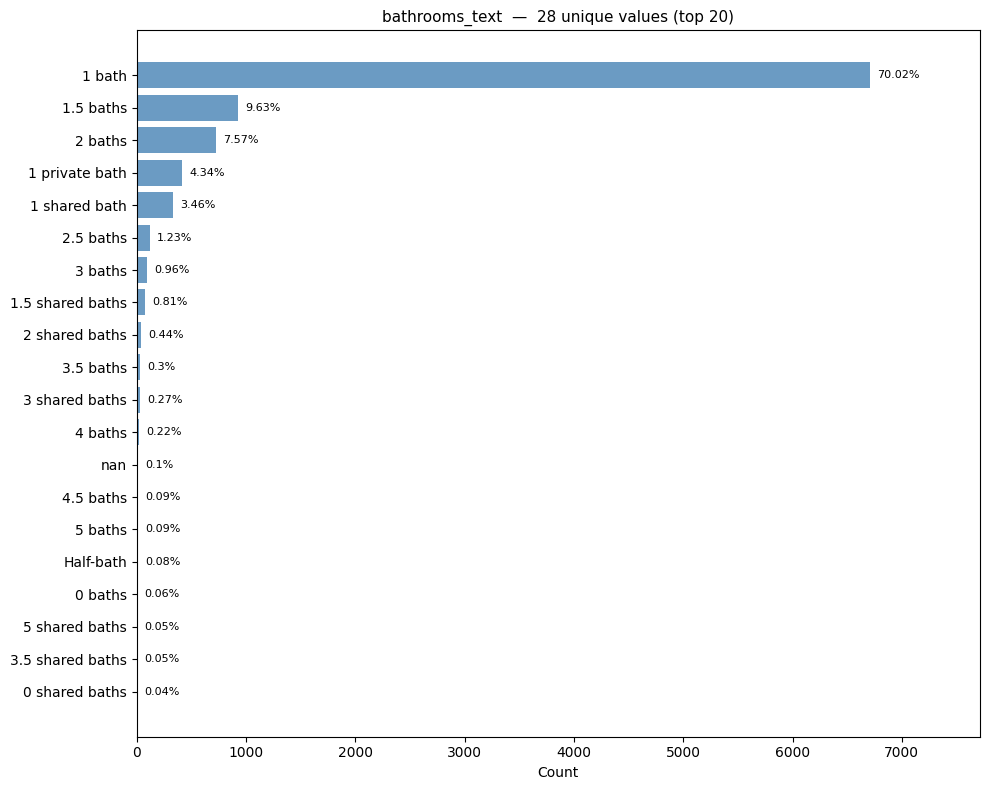

C:\Users\dinat\AppData\Local\Temp\ipykernel_1904\2083567036.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


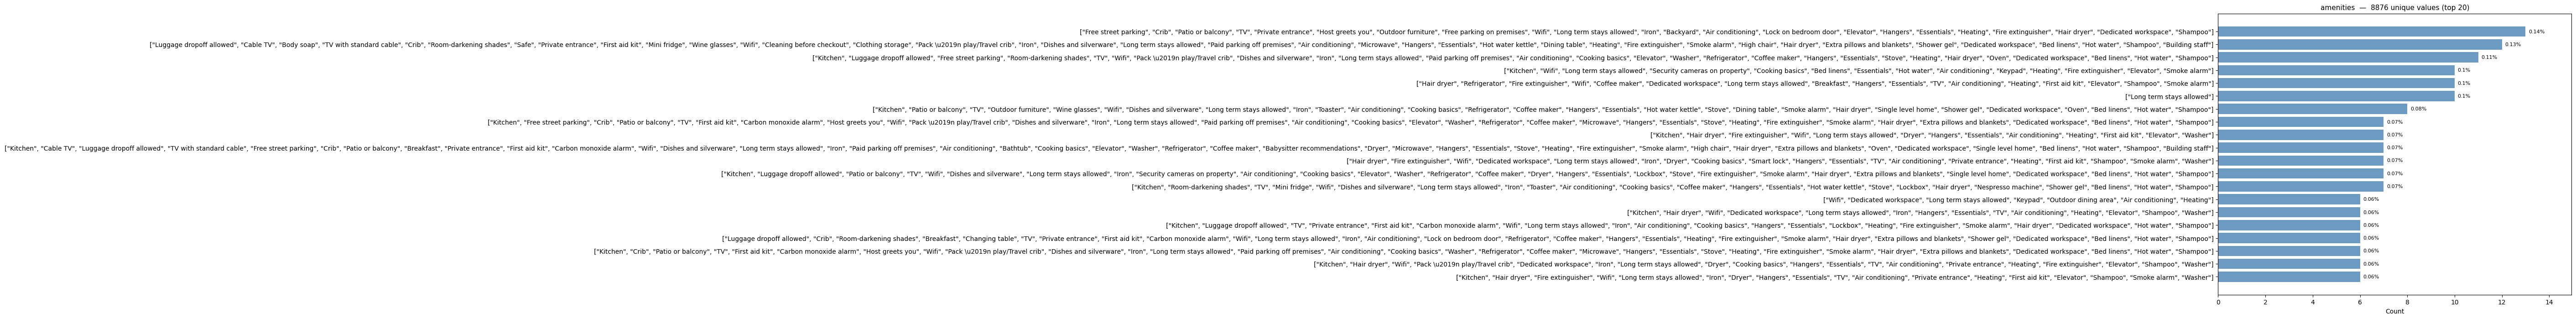

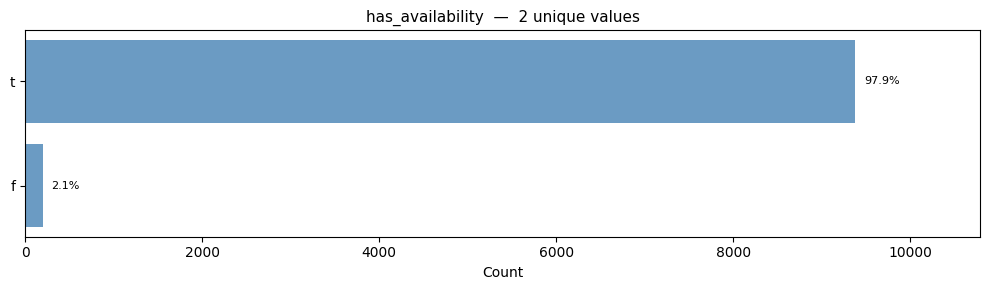

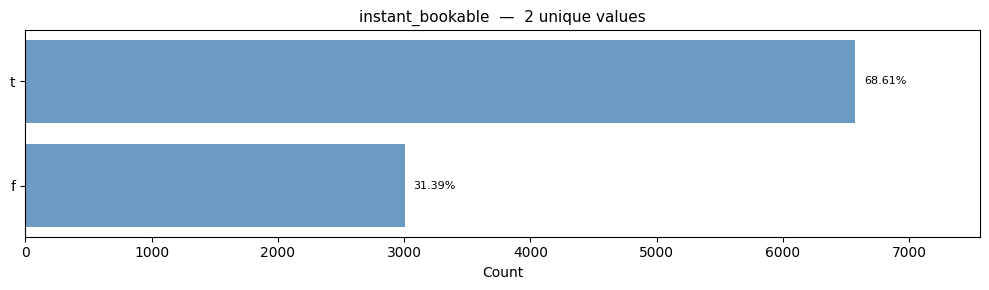

In [161]:
# ── Categorical Column Value Frequencies (plots) ──────────────────────────────

cat_cols = data.select_dtypes(include="object").columns.tolist()

for col in cat_cols:
    vc = data[col].value_counts(dropna=False)
    pct = (vc / len(data) * 100).round(2)

    # For high-cardinality columns, show only top 20
    if len(vc) > 20:
        vc = vc.head(20)
        pct = pct.head(20)
        title_suffix = " (top 20)"
    else:
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(10, max(3, len(vc) * 0.4)))
    bars = ax.barh(vc.index.astype(str)[::-1], vc.values[::-1], color="steelblue", alpha=0.8)

    # Annotate bars with percentage
    for bar, p in zip(bars, pct.values[::-1]):
        ax.text(bar.get_width() + vc.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{p}%", va="center", fontsize=8)

    ax.set_title(f"{col}  —  {data[col].nunique()} unique values{title_suffix}", fontsize=11)
    ax.set_xlabel("Count")
    ax.margins(x=0.15)
    plt.tight_layout()
    plt.show()

In [162]:
import ast

# ── Binary encoding for list-valued columns ───────────────────────────────────

def parse_list_column(series: pd.Series) -> pd.Series:
    def parse(val):
        if pd.isna(val) or val == "":
            return []
        try:
            result = ast.literal_eval(val)
            if isinstance(result, list):
                return [str(v).strip().lower() for v in result]
        except (ValueError, SyntaxError):
            pass
        val = str(val).strip("[]").replace('"', '').replace("'", "")
        return [v.strip().lower() for v in val.split(",") if v.strip()]
    return series.apply(parse)

def encode_list_column(df: pd.DataFrame, col: str, prefix: str = None, min_freq: float = 0.05) -> pd.DataFrame:
    prefix = prefix or col
    parsed = parse_list_column(df[col])
    n_rows = len(df)

    # Count how many rows each value appears in
    from collections import Counter
    value_counts = Counter(v for row in parsed for v in row if v)

    all_values = sorted(value_counts.keys())
    frequent_values = [v for v in all_values if value_counts[v] / n_rows >= min_freq]
    dropped_values  = [v for v in all_values if value_counts[v] / n_rows < min_freq]

    print(f"\n{col}: {len(all_values)} unique values total")
    print(f"  → keeping  {len(frequent_values)} values (>= {min_freq*100:.0f}% frequency)")
    print(f"  → dropping {len(dropped_values)} rare values")

    for val in frequent_values:
        safe_name = f"{prefix}__{val.replace(' ', '_').replace('/', '_').replace('-', '_')}"
        df[safe_name] = parsed.apply(lambda lst: 1 if val in lst else 0)

    df.drop(columns=[col], inplace=True)
    return df


data = encode_list_column(data, "host_verifications", prefix="hostverif", min_freq=0.1)
data = encode_list_column(data, "amenities", prefix="amenity", min_freq=0.1)

print(f"\nNew shape: {data.shape}")


host_verifications: 19 unique values total
  → keeping  10 values (>= 10% frequency)
  → dropping 9 rare values

amenities: 875 unique values total
  → keeping  56 values (>= 10% frequency)
  → dropping 819 rare values

New shape: (9582, 98)


In [163]:
# ── Parse bathrooms_text → bath_count + bath_is_shared ───────────────────────

def parse_bathrooms_text(series: pd.Series):
    bath_count = []
    bath_shared = []

    for val in series:
        if pd.isna(val):
            bath_count.append(np.nan)
            bath_shared.append(np.nan)
            continue

        val_lower = str(val).strip().lower()

        # Shared flag
        is_shared = 1 if "shared" in val_lower else 0

        # Extract numeric part
        if "half" in val_lower:
            count = 0.5
        else:
            # Pull first number (int or float) from the string
            match = re.search(r"(\d+\.?\d*)", val_lower)
            count = float(match.group(1)) if match else np.nan

        bath_count.append(count)
        bath_shared.append(is_shared)

    return bath_count, bath_shared

import re

counts, shared = parse_bathrooms_text(data["bathrooms_text"])
data["bath_count"] = counts
data["bath_is_shared"] = shared

data.drop(columns=["bathrooms_text"], inplace=True)

print("Sample result:")
display(data[["bath_count", "bath_is_shared"]].value_counts().head(10).reset_index())
print(f"\nbath_count  — missing: {data['bath_count'].isna().sum()}")
print(f"bath_is_shared — missing: {data['bath_is_shared'].isna().sum()}")

Sample result:


,bath_count,bath_is_shared,count
0,1.0,0.0,7125
1,1.5,0.0,923
2,2.0,0.0,725
3,1.0,1.0,332
4,2.5,0.0,118
5,3.0,0.0,92
6,1.5,1.0,78
7,2.0,1.0,42
8,3.5,0.0,29
9,3.0,1.0,26



bath_count  — missing: 10
bath_is_shared — missing: 10


In [164]:
# ── Convert rate columns from "75%" string → 0.75 float ─────────────────────

rate_cols = ["host_acceptance_rate", "host_response_rate"]
rate_cols = [c for c in rate_cols if c in data.columns]

for col in rate_cols:
    data[col] = (
        data[col].astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
        .pipe(pd.to_numeric, errors="coerce")
        .div(100)
    )
    print(f"  {col}: range {data[col].min():.2f} – {data[col].max():.2f}  |  missing: {data[col].isna().sum()}")

  host_acceptance_rate: range 0.00 – 1.00  |  missing: 2304
  host_response_rate: range 0.00 – 1.00  |  missing: 2244


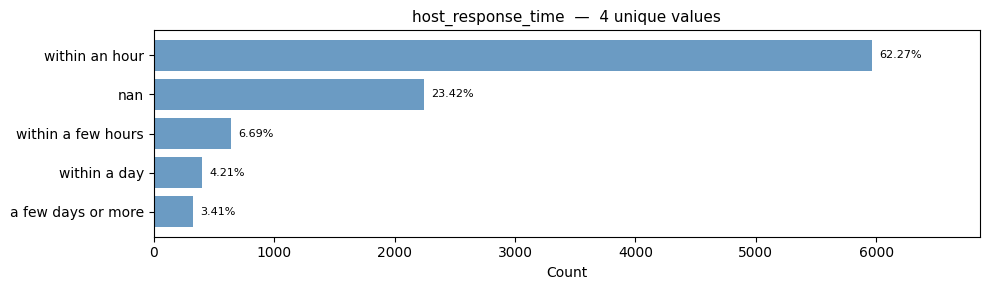

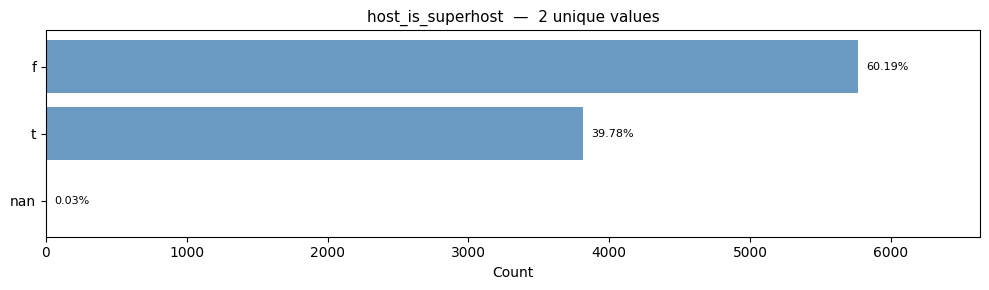

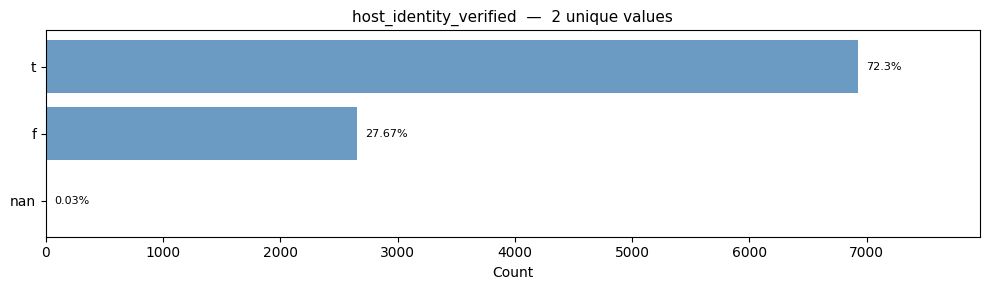

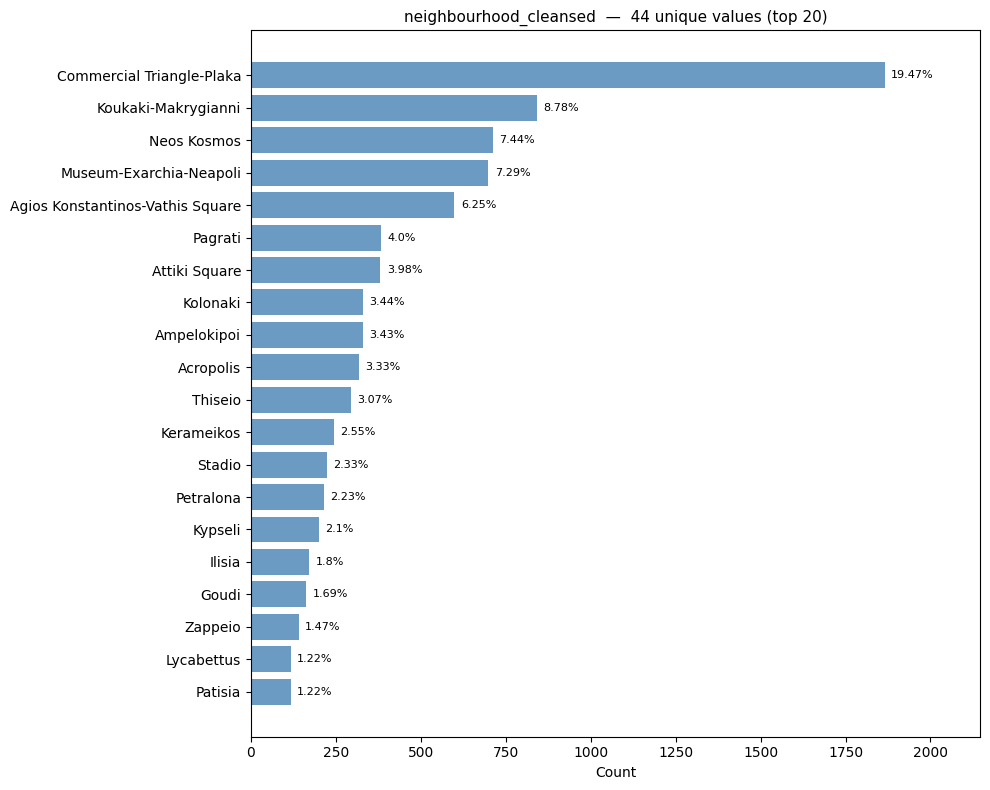

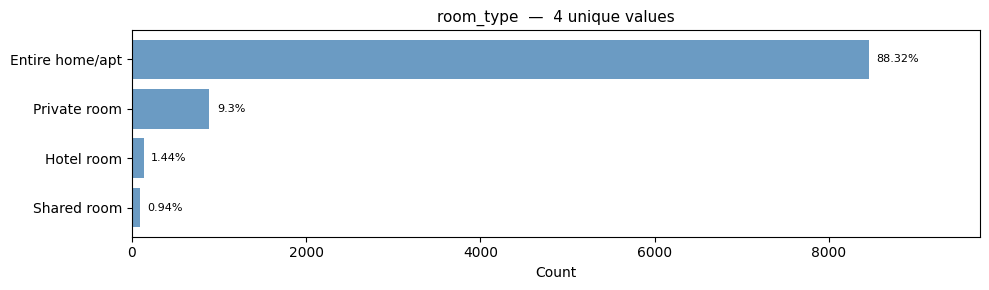

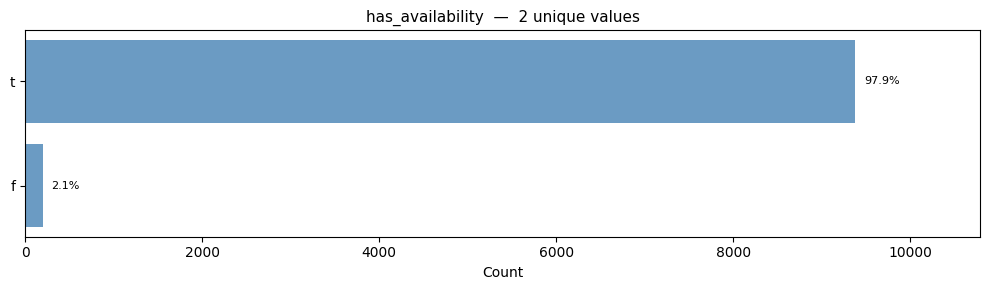

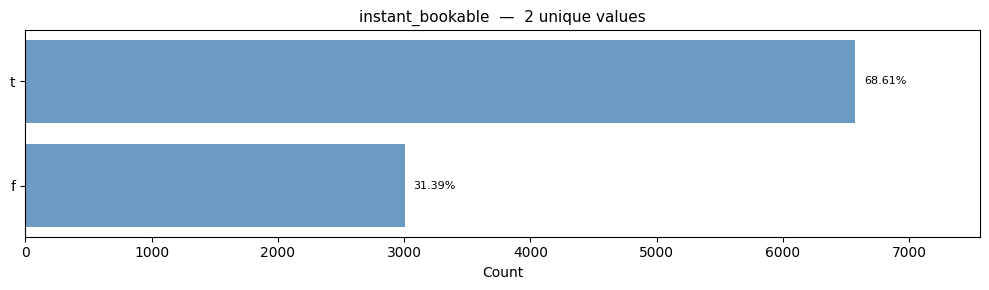

In [165]:
# ── Categorical Column Value Frequencies (plots) ──────────────────────────────

cat_cols = data.select_dtypes(include="object").columns.tolist()

for col in cat_cols:
    vc = data[col].value_counts(dropna=False)
    pct = (vc / len(data) * 100).round(2)

    # For high-cardinality columns, show only top 20
    if len(vc) > 20:
        vc = vc.head(20)
        pct = pct.head(20)
        title_suffix = " (top 20)"
    else:
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(10, max(3, len(vc) * 0.4)))
    bars = ax.barh(vc.index.astype(str)[::-1], vc.values[::-1], color="steelblue", alpha=0.8)

    # Annotate bars with percentage
    for bar, p in zip(bars, pct.values[::-1]):
        ax.text(bar.get_width() + vc.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{p}%", va="center", fontsize=8)

    ax.set_title(f"{col}  —  {data[col].nunique()} unique values{title_suffix}", fontsize=11)
    ax.set_xlabel("Count")
    ax.margins(x=0.15)
    plt.tight_layout()
    plt.show()

In [166]:
# ── Impute missing values (drop if >30% missing) ──────────────────────────────

DROP_THRESHOLD = 0.30

# Identify and drop columns with >30% missing
high_missing = [col for col in data.columns if data[col].isna().mean() > DROP_THRESHOLD]
if high_missing:
    print(f"Dropping {len(high_missing)} columns with >30% missing values:")
    for col in high_missing:
        print(f"  ✗ {col}  ({data[col].isna().mean()*100:.1f}% missing)")
    data.drop(columns=high_missing, inplace=True)

# Numeric columns → median
numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns
for col in numeric_cols:
    n_missing = data[col].isna().sum()
    if n_missing > 0:
        median_val = data[col].median()
        data[col] = data[col].fillna(median_val)
        print(f"  [numeric]  {col}: filled {n_missing} NaN → median={median_val:.4g}")

# Categorical columns → mode
cat_cols = data.select_dtypes(include="object").columns
for col in cat_cols:
    n_missing = data[col].isna().sum()
    if n_missing > 0:
        mode_val = data[col].mode()
        fill_val = mode_val[0] if not mode_val.empty else "Unknown"
        data[col] = data[col].fillna(fill_val)
        print(f"  [categorical] {col}: filled {n_missing} NaN → mode='{fill_val}'")

print(f"\nFinal shape: {data.shape}")
print(f"Total remaining NaN: {data.isna().sum().sum()}")

  [numeric]  host_response_rate: filled 2244 NaN → median=1
  [numeric]  host_acceptance_rate: filled 2304 NaN → median=1
  [numeric]  host_listings_count: filled 3 NaN → median=3
  [numeric]  bedrooms: filled 813 NaN → median=1
  [numeric]  beds: filled 68 NaN → median=2
  [numeric]  reviews_per_month: filled 1708 NaN → median=1.2
  [numeric]  days_since_first_review: filled 1708 NaN → median=876
  [numeric]  days_since_last_review: filled 1708 NaN → median=87
  [numeric]  bath_count: filled 10 NaN → median=1
  [numeric]  bath_is_shared: filled 10 NaN → median=0
  [categorical] host_response_time: filled 2244 NaN → mode='within an hour'
  [categorical] host_is_superhost: filled 3 NaN → mode='f'
  [categorical] host_identity_verified: filled 3 NaN → mode='t'

Final shape: (9582, 99)
Total remaining NaN: 0


In [167]:
# ── One-Hot Encode remaining categorical columns ──────────────────────────────

# Boolean-like columns (t/f) → 0/1 directly
bool_map = {"t": 1, "f": 0, "true": 1, "false": 0}
bool_cols = [
    col for col in data.select_dtypes(include="object").columns
    if set(data[col].dropna().str.lower().str.strip().unique()).issubset({"t", "f", "true", "false"})
]
for col in bool_cols:
    data[col] = data[col].str.lower().str.strip().map(bool_map)
    print(f"  [binary]  {col} → 0/1")

# One-hot encode remaining object columns
cat_cols_remaining = data.select_dtypes(include="object").columns.tolist()
print(f"\nOne-hot encoding {len(cat_cols_remaining)} columns:")
for col in cat_cols_remaining:
    print(f"  {col}  ({data[col].nunique()} unique values)")

data = pd.get_dummies(data, columns=cat_cols_remaining, drop_first=False, dtype=int)

print(f"\nFinal shape after encoding: {data.shape}")
print(f"Remaining object columns: {data.select_dtypes(include='object').columns.tolist()}")

  [binary]  host_is_superhost → 0/1
  [binary]  host_identity_verified → 0/1
  [binary]  has_availability → 0/1
  [binary]  instant_bookable → 0/1

One-hot encoding 3 columns:
  host_response_time  (4 unique values)
  neighbourhood_cleansed  (44 unique values)
  room_type  (4 unique values)

Final shape after encoding: (9582, 148)
Remaining object columns: []


In [169]:
data.to_csv(project_root / "data/cleaned_listings.csv", index=False)